In [ ]:
#!pip install torchviz

In [3]:
from tkinter import X
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchviz import make_dot

class VisionTransformer(nn.Module):
    """Vision Transformer (ViT) 模型实现

    该模型将图像分成固定大小的patch,通过Transformer架构处理这些patch序列来进行图像分类

    Args:
        num_classes (int): 分类类别数,默认10
        num_layers (int): Transformer编码器层数,默认12
        num_heads (int): 多头注意力头数,默认8
        hidden_dim (int): 隐藏层维度,默认768
        mlp_dim (int): MLP中间层维度,默认3072
        patch_size (int): 图像patch大小,默认16
        img_size (int): 输入图像大小,默认224
    """
    def __init__(self, num_classes=10, num_layers=12, num_heads=8, hidden_dim=768, mlp_dim=3072, patch_size=16, img_size=224):
        super().__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        self.mlp_dim = mlp_dim
        self.patch_size = patch_size
        self.img_size = img_size

        # 创建补丁嵌入层 - 使用卷积实现patch embedding,将图像划分为patch_size x patch_size大小的patch
        self.patch_embeddings = nn.Conv2d(in_channels=3,  # 输入通道数为3(RGB)
                                           out_channels=hidden_dim,  # 输出通道数等于隐藏维度
                                           kernel_size=patch_size,  # 卷积核大小等于patch大小,默认16
                                           stride=patch_size)  # 步长等于patch大小,确保patch不重叠

        # 位置嵌入 - 为每个patch添加位置信息
        # (img_size // patch_size) ** 2 =224/16=14,计算patch总数,+1是为了加上cls token

        # 维度为 (1, num_patches + 1, hidden_dim)，nn.Parameter接口创建可训练参数,优化器,224/16=14，+1是为了加上cls token
        self.position_embeddings = nn.Parameter(torch.zeros(1, (img_size // patch_size) ** 2 + 1, hidden_dim))  # 创建位置嵌入参数

        # 分类token - 可学习的特殊token,用于最终的分类任务
        # 维度为 (1, 1, hidden_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))

        # Transformer编码器层 - 包含self-attention和feed forward网络
        self.transformer_blocks = nn.ModuleList(
            [nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads) for _ in range(num_layers)]
        )

        # 分类头 - 将最终的cls token特征映射到类别空间
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        """前向传播函数

        Args:
            x (torch.Tensor): 输入图像张量,shape为(batch_size, 3, img_size, img_size)

        Returns:
            torch.Tensor: 分类logits,shape为(batch_size, num_classes)
        """
        # 步骤1: patch embedding - 将图像转换为patch序列,h=w=14
        x = self.patch_embeddings(x)  # 输出shape: (batch_size, hidden_dim, h, w)
        print(f'position_embeddings后: {x.shape}') # (1,768,14,14)

        # 将特征图重排为序列形式，num_patches=h*w=seq_len=14*14=196
        x = x.flatten(2).transpose(1, 2)  # 输出shape: (batch_size, num_patches, hidden_dim)

        # 步骤2: 添加分类token
        batch_size = x.shape[0]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # 扩展cls token到batch size
        # 将cls token和特征图拼接
        x = torch.cat((cls_tokens, x), dim=1)  # 在序列维度上拼接cls token


        # 步骤3: 添加位置编码
        x += self.position_embeddings  # 加入位置信息,(batch_size, num_patches+1, hidden_dim)=(1, 197, 768)

        # 步骤4: 通过Transformer编码器层
        for transformer in self.transformer_blocks:
            x = transformer(x)  # 依次通过每个Transformer层

        print(f'transformer后: {x.shape}')

        # 步骤5: 提取cls token并进行分类
        x = x[:, 0]  # 只使用cls token的特征,shape: (batch_size, hidden_dim)
        x = self.fc(x)  # 通过分类头得到最终logits
        return x

def generate_random_image(size=(3, 224, 224)):
    """生成随机测试图像

    Args:
        size (tuple): 图像尺寸,默认(3,224,224)

    Returns:
        np.ndarray: 随机生成的图像数组
    """
    return np.random.rand(*size).astype(np.float32)

def main():
    """主函数 - 模型测试"""
    # 初始化ViT模型
    model = VisionTransformer(num_classes=1000)
    model.eval()  # 设置为评估模式

    # 生成测试输入
    random_image = generate_random_image()
    input_tensor = torch.from_numpy(random_image).unsqueeze(0)  # 添加batch维度

    # 模型推理
    with torch.no_grad():  # 关闭梯度计算
        logits = model(input_tensor)

    # 打印输出shape
    print('Logits:', logits.shape)

    # 可视化相关代码(已注释)
    # y = model(input_tensor)
    # dot = make_dot(y, params=dict(model.named_parameters()))
    # dot.format = 'png'
    # dot.render('vit_model_structure', cleanup=True, view=False)

    # plt.imshow(random_image.transpose(1, 2, 0))
    # plt.title('Randomly Generated Image')
    # plt.axis('off')
    # plt.show()

if __name__ == "__main__":
    main()

position_embeddings后: torch.Size([1, 768, 14, 14])
transformer后: torch.Size([1, 197, 768])
Logits: torch.Size([1, 1000])


输入图像尺寸: torch.Size([1, 3, 224, 224])
Transformer模块输出尺寸: torch.Size([1, 197, 768])
Logits尺寸: torch.Size([1, 1000])
Predicted class: Egyptian cat


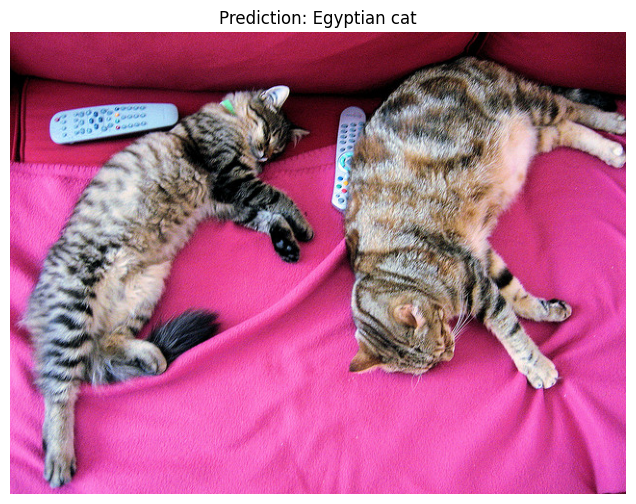

In [10]:
#梯子必须开启
# 使用transformers库的ViT模型进行图像预测
from transformers import ViTFeatureExtractor, ViTForImageClassification  # 导入ViT模型相关组件
from PIL import Image  # 导入图像处理库
import requests  # 导入网络请求库
import torch  # 导入PyTorch
import matplotlib.pyplot as plt  # 导入绘图库

def predict_with_transformers_vit():
    """使用预训练的ViT模型进行图像分类预测

    该函数完成以下功能:
    1. 加载预训练的ViT模型和特征提取器
    2. 从网络下载示例图片并进行预处理
    3. 使用模型进行预测并获取中间层输出
    4. 可视化预测结果

    Returns:
        None: 函数将打印预测结果并显示带预测标签的图像
    """
    # 加载预训练的ViT模型和特征提取器 - 使用google预训练的base模型,patch size为16x16
    feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224')
    model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

    # 下载COCO数据集中的示例图片 - 使用requests获取在线图片，12位数字
    url = 'http://images.cocodataset.org/val2017/000000039769.jpg'


    image = Image.open(requests.get(url, stream=True).raw)

    # 使用特征提取器预处理图像 - 调整大小、归一化等操作
    inputs = feature_extractor(images=image, return_tensors="pt")
    print(f"输入图像尺寸: {inputs['pixel_values'].shape}")  # 打印预处理后的输入张量形状

    # 进行预测，获取Transformer模块的输出 - 使用no_grad避免计算梯度
    with torch.no_grad():
        # 定义变量存储Transformer模块的输出
        transformer_output = None

        def hook_fn(module, input, output):
            """钩子函数 - 用于获取中间层输出,函数里嵌套函数是python中的闭包

            Args:
                module: 触发钩子的模块
                input: 模块的输入
                output: 模块的输出
            """
            nonlocal transformer_output
            transformer_output = output

        # 注册钩子到Transformer编码器模块 - 用于获取中间层特征，register_forward_hook接口允许我们注册一个函数，当模块的forward方法被调用时，这个函数会被调用。
        hook = model.vit.encoder.register_forward_hook(hook_fn)

        # 执行模型前向传播 - 获取预测结果
        outputs = model(**inputs)

        # 移除钩子 - 避免内存泄漏
        hook.remove()

    # 打印Transformer编码器输出维度信息
    print(f"Transformer模块输出尺寸: {transformer_output.last_hidden_state.shape}")

    # 获取模型预测的logits并找出最可能的类别
    logits = outputs.logits
    print(f"Logits尺寸: {logits.shape}")  # 打印输出logits的形状
    predicted_class_idx = logits.argmax(-1).item()  # 获取预测概率最高的类别索引

    # 将预测的类别索引转换为可读的类别名称
    predicted_class = model.config.id2label[predicted_class_idx]

    # 打印预测结果
    print(f"Predicted class: {predicted_class}")

    # 可视化结果 - 显示原始图像和预测标签
    plt.figure(figsize=(8, 6))  # 设置图像显示大小
    plt.imshow(image)  # 显示原始图像
    plt.title(f'Prediction: {predicted_class}')  # 添加预测结果作为标题
    plt.axis('off')  # 关闭坐标轴显示
    plt.show()  # 展示图像

# 执行预测函数
predict_with_transformers_vit()
